Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


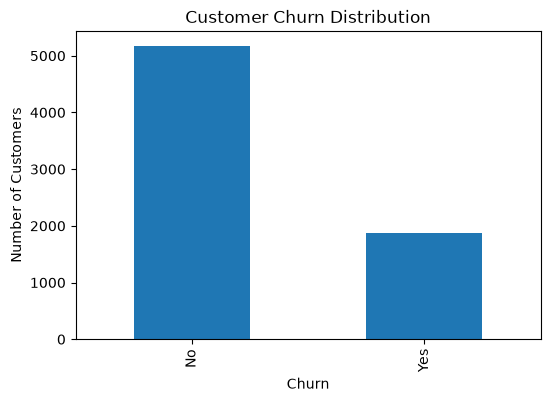

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
df = pd.read_csv("../data/processed/telco_customer_churn_clean.csv")
df.head()
churn_counts = df["Churn"].value_counts()

print(churn_counts)
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)
plt.figure(figsize=(6,4))

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Chart Interpretation: Customer Churn Distribution

The bar chart provides a visual comparison between customers who remained with the company and those who discontinued their services. It clearly shows that the number of retained customers is significantly higher than the number of churned customers, with approximately **73.46%** of customers remaining active and **26.54%** leaving the company.

Although customer retention currently exceeds customer attrition, the chart highlights that more than one-quarter of the customer base has churned. For a subscription-based telecom business, this represents a considerable loss of recurring revenue and may lead to increased costs associated with acquiring new customers to replace those who have left.

The imbalance observed in the chart suggests that while the company has a relatively stable customer base, there is still a substantial opportunity to improve customer retention. Further analysis is therefore required to identify the characteristics of churned customers and determine the factors contributing to customer attrition. These insights will help the company develop targeted retention strategies aimed at reducing churn and improving long-term profitability.

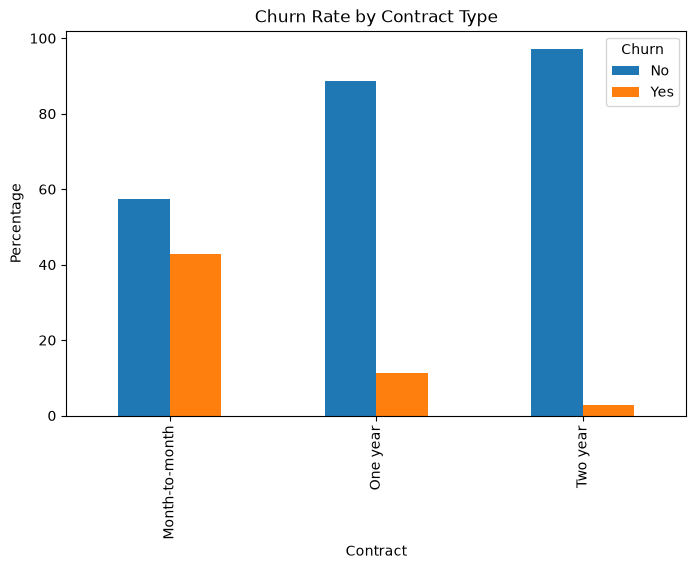

In [3]:
pd.crosstab(df["Contract"], df["Churn"])

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

contract_churn.plot(kind="bar", figsize=(8,5))

plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.show()

## Which Contract Type Has the Highest Churn?

Customers on month-to-month contracts exhibit substantially higher churn rates than those on one-year or two-year contracts. This suggests that longer-term contracts improve customer retention and provide more predictable revenue.

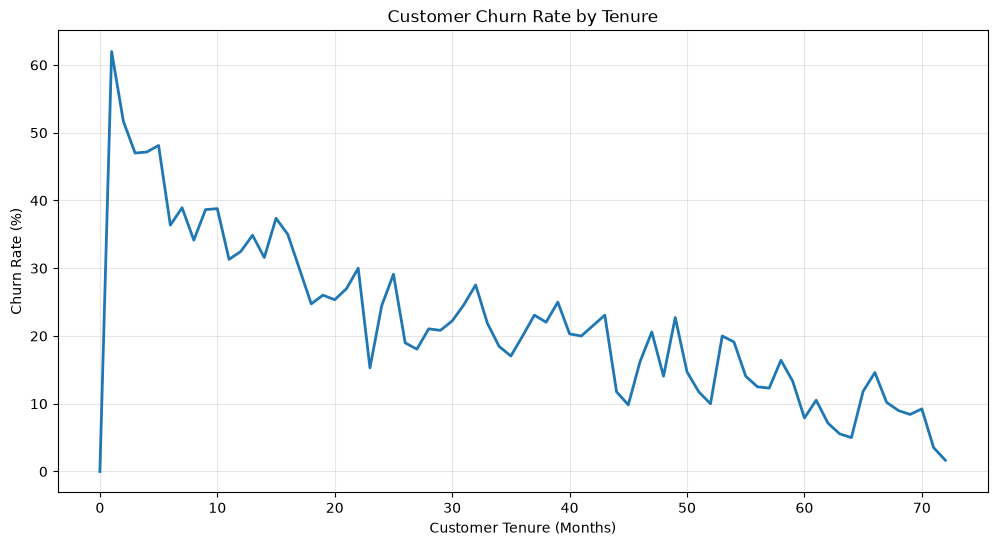

In [4]:
tenure_churn.head()
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    tenure_churn["tenure"],
    tenure_churn["Churn"],
    linewidth=2
)

plt.title("Customer Churn Rate by Tenure")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Churn Rate (%)")

plt.grid(alpha=0.3)

plt.show()

### Chart Relationship Between Customer Tenure and Customer Churn

The line chart illustrates how the customer churn rate changes as tenure increases. The highest churn rates are observed among customers with shorter tenures, indicating that new customers are more likely to leave the company. As tenure increases, the churn rate generally declines, suggesting that customers become more loyal the longer they remain with the service.

This trend indicates that customer retention improves over time, with long-term customers showing a significantly lower likelihood of churning compared to recently acquired customers.

### Business Insight

The analysis suggests that the first year of a customer's relationship with the company is the most critical period for retention. The company should prioritize onboarding programs, proactive customer support, and targeted promotional offers during the early months of service to reduce churn and increase long-term customer loyalty.

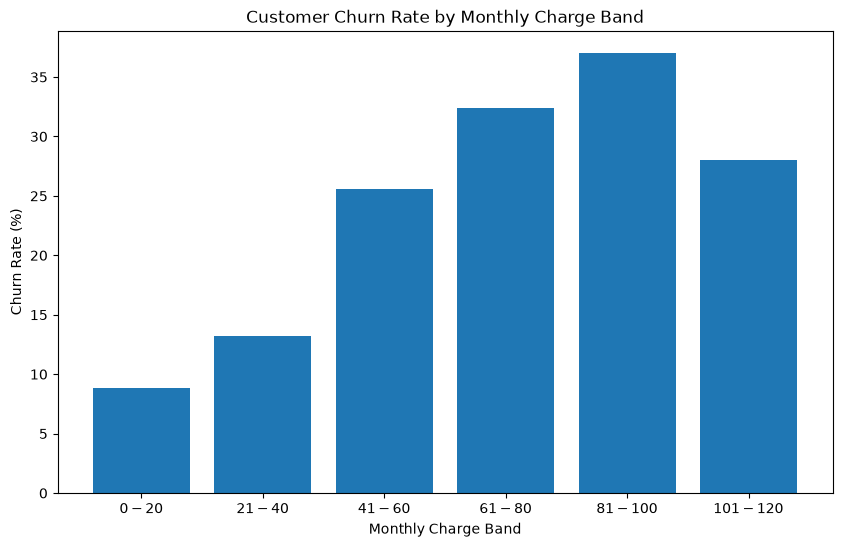

In [5]:
df.groupby("Churn")["MonthlyCharges"].describe()
bins = [0,20,40,60,80,100,120]

labels = [
    "$0-$20",
    "$21-$40",
    "$41-$60",
    "$61-$80",
    "$81-$100",
    "$101-$120"
]

df["ChargeBand"] = pd.cut(
    df["MonthlyCharges"],
    bins=bins,
    labels=labels
)

monthly = (
    df.groupby("ChargeBand")["Churn"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .reset_index()
)
plt.figure(figsize=(10,6))

plt.bar(
    monthly["ChargeBand"],
    monthly["Churn"]
)

plt.title("Customer Churn Rate by Monthly Charge Band")
plt.xlabel("Monthly Charge Band")
plt.ylabel("Churn Rate (%)")

plt.show()

Impact of Monthly Charges on Customer Churn

The chart shows the relationship between monthly charge bands and customer churn. As monthly charges increase, the proportion of customers who churn generally increases, indicating a positive relationship between service cost and customer attrition.

This observation is supported by the summary statistics, where customers who churned paid an average monthly charge of **$74.44**, compared to **$61.27** for customers who remained with the company. This difference suggests that customers on higher-priced plans are more likely to discontinue their services than those on lower-priced plans.

### Business Insight

Monthly service charges appear to be an important factor influencing customer retention. Customers paying premium prices may have higher expectations regarding service quality, reliability, and overall value. If these expectations are not met, they may be more willing to switch to competitors offering similar services at lower prices or with better customer experiences.

### Recommendation

The company should closely monitor customers subscribed to higher-priced plans and implement targeted retention strategies, such as personalized discounts, loyalty rewards, value-added service bundles, or proactive customer support. Improving the perceived value of premium plans could help reduce churn among high-value customers and protect recurring revenue.

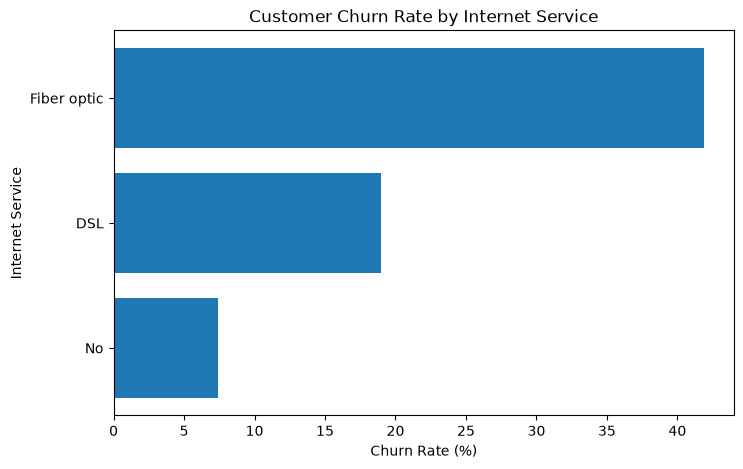

In [6]:
internet_churn
internet = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda x:(x=="Yes").mean()*100)
      .sort_values()
)

plt.figure(figsize=(8,5))

plt.barh(
    internet.index,
    internet.values
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Internet Service")
plt.title("Customer Churn Rate by Internet Service")

plt.show()

Customer Churn Rate by Internet Service

The analysis reveals a significant relationship between internet service type and customer churn. Customers subscribed to **Fiber Optic** internet services experienced the highest churn rate at **41.89%**, meaning that nearly two out of every five Fiber Optic customers discontinued their service. In comparison, **DSL** customers had a much lower churn rate of **18.96%**, while customers without an internet service recorded the lowest churn rate of only **7.40%**.

The large difference in churn rates suggests that internet service type plays an important role in customer retention. Fiber Optic customers are considerably more likely to leave the company than customers using other internet service options.

### Business Insight

The high churn rate among Fiber Optic customers may indicate issues related to pricing, service quality, network reliability, or customer expectations. Although Fiber Optic is typically a premium service, customers may perceive that the value received does not justify the cost, making them more likely to switch to competing providers.

On the other hand, the relatively low churn rates among DSL customers and customers without internet service suggest greater customer stability and satisfaction within these groups.

### Recommendation

The company should prioritize an in-depth investigation into the Fiber Optic customer segment to identify the primary causes of churn. Conducting customer satisfaction surveys, reviewing pricing strategies, improving network performance, and offering targeted loyalty incentives to Fiber Optic subscribers could help reduce customer attrition. Since Fiber Optic customers represent the highest-risk segment, improving retention within this group is likely to have the greatest impact on reducing overall churn and increasing long-term revenue.

## Key Findings and Business Insights

The exploratory data analysis reveals several important patterns associated with customer churn within the telecom customer base. Overall, **26.54% of customers have churned**, while **73.46% remain with the company**. Although the majority of customers are retained, losing more than one-quarter of the customer base represents a significant business challenge, particularly for a subscription-based telecom company that depends on recurring revenue.

The analysis indicates that **customer tenure is strongly associated with churn**. Customers with shorter relationships with the company are considerably more likely to leave, while churn generally decreases as tenure increases. This suggests that the early stages of the customer lifecycle represent a critical retention period. The company should therefore strengthen onboarding, provide proactive customer support, and introduce early-stage engagement and loyalty initiatives to help new customers develop long-term relationships with the service.

**Contract type** also appears to be a major factor influencing customer retention. Customers on month-to-month contracts exhibit substantially higher churn than those committed to one-year or two-year contracts. This suggests that customers with greater contractual commitment are more likely to remain with the company. The business could potentially reduce churn by encouraging month-to-month customers to transition to longer-term contracts through loyalty incentives, discounts, or additional service benefits.

The analysis also identifies a relationship between **monthly charges and customer churn**. Customers who churned had an average monthly charge of **$74.44**, compared with **$61.27** among customers who remained. This suggests that customers paying higher monthly fees may be more sensitive to pricing or may have higher expectations regarding service quality and value. The company should therefore review the value proposition of higher-priced plans and consider targeted retention offers for high-value customers who may be at risk of leaving.

**Internet service type** further highlights a significant difference in customer retention. Fiber Optic customers recorded the highest churn rate at **41.89%**, compared with **18.96%** for DSL customers and **7.40%** for customers without internet service. The substantially higher churn among Fiber Optic customers makes this segment a priority for further investigation. Potential factors such as pricing, network reliability, service quality, customer expectations, and competitive alternatives should be examined to determine why this customer group experiences such high attrition.

### Overall Business Implications

Taken together, the findings suggest that customer churn is not driven by a single factor. Instead, churn appears to be associated with a combination of **customer tenure, contract commitment, monthly pricing, and internet service type**. The highest-risk customers are likely to be those who are relatively new to the company, remain on flexible month-to-month contracts, pay relatively high monthly charges, or subscribe to Fiber Optic services.

### Recommended Retention Strategy

Based on these findings, the company should adopt a targeted, segment-based retention strategy rather than applying the same approach to all customers. Priority should be given to:

1. **New customers** – Introduce stronger onboarding and early engagement programs during the first year of service.

2. **Month-to-month customers** – Encourage migration to longer-term contracts through discounts, loyalty benefits, and attractive service bundles.

3. **High-paying customers** – Review pricing and perceived value while providing personalized retention offers to customers at high risk of churn.

4. **Fiber Optic customers** – Investigate service quality, pricing, network performance, and customer satisfaction to identify the causes of the unusually high churn rate.

By focusing retention efforts on these high-risk segments, the company can potentially reduce customer attrition, protect recurring revenue, increase customer lifetime value, and improve long-term profitability.

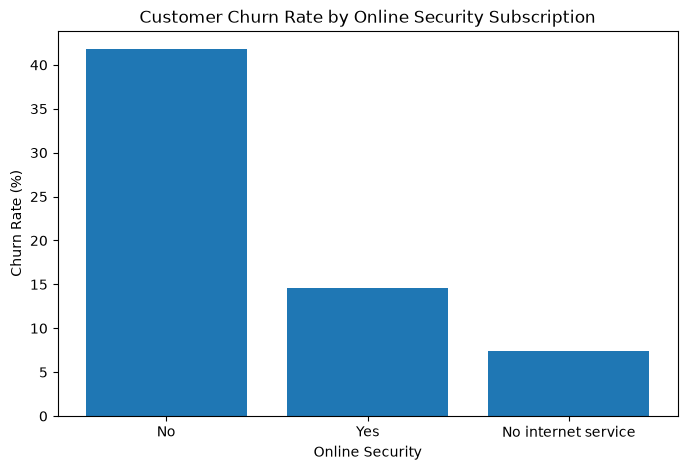

In [9]:
online_security_churn = (
    df.groupby("OnlineSecurity")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

online_security_churn
plt.figure(figsize=(8,5))

plt.bar(
    online_security_churn.index,
    online_security_churn.values
)

plt.title("Customer Churn Rate by Online Security Subscription")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

plt.show()

Customer Churn Rate by Online Security Subscription

The analysis reveals a substantial difference in churn rates based on customers' Online Security subscription status. Customers who do not subscribe to Online Security have the highest churn rate at **41.77%**. In comparison, customers who subscribe to Online Security have a significantly lower churn rate of **14.61%**, while customers without internet service record the lowest churn rate at **7.40%**.

The difference between customers with and without Online Security is particularly notable. Customers without the service experience a churn rate that is nearly three times higher than those who subscribe to it. This suggests that the availability and adoption of additional security services may be associated with stronger customer retention.

### Business Insight

The findings indicate that customers without Online Security represent a high-risk segment for customer churn. Customers who subscribe to the service may perceive greater value in their overall telecom package, which could contribute to stronger customer loyalty and a lower likelihood of leaving the company.

However, the analysis identifies an association rather than proving that Online Security directly prevents churn. Other factors, such as contract type, tenure, pricing, and internet service, may also influence the relationship between Online Security and customer retention.

### Recommendation

The company should consider promoting Online Security as part of targeted retention and service-bundling strategies, particularly among customers who currently do not subscribe to the service. Offering discounted security packages, bundled plans, or free trials could increase service adoption while potentially improving customer retention. Further analysis should also examine whether the relationship remains significant after accounting for other factors such as contract type, tenure, and monthly charges.

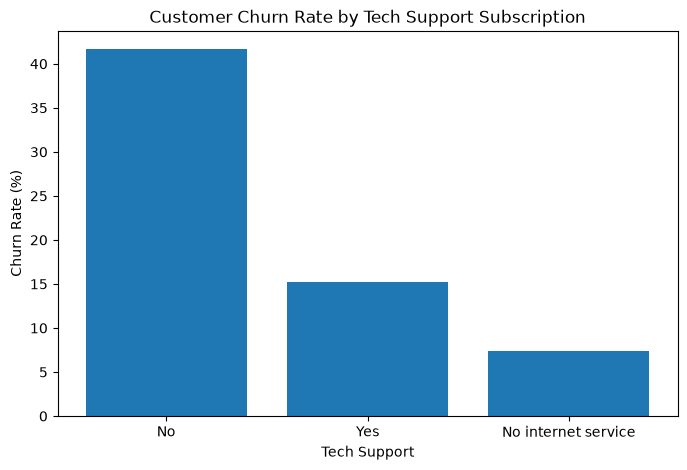

In [15]:
tech_support_churn = (
    df.groupby("TechSupport")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

tech_support_churn
plt.figure(figsize=(8,5))

plt.bar(
    tech_support_churn.index,
    tech_support_churn.values
)

plt.title("Customer Churn Rate by Tech Support Subscription")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

plt.show()

Customer Churn Rate by Tech Support Subscription

The analysis reveals a substantial difference in customer churn rates based on Tech Support subscription status. Customers who do not subscribe to Tech Support have the highest churn rate at **41.64%**. In contrast, customers who subscribe to Tech Support have a significantly lower churn rate of **15.17%**, while customers without internet service record the lowest churn rate at **7.40%**.

The difference between customers with and without Tech Support is particularly significant. Customers without the service experience a churn rate that is more than twice as high as customers who subscribe to Tech Support. This suggests that access to technical assistance and support services may be associated with stronger customer retention.

### Business Insight

Customers without Tech Support represent a high-risk segment for customer churn. Customers who subscribe to Tech Support may perceive greater value from their overall service package and may have better access to assistance when experiencing technical issues, potentially contributing to higher customer retention.

However, this analysis identifies an association rather than proving that Tech Support directly prevents churn. Other factors, including contract type, tenure, monthly charges, and internet service type, may also influence the relationship between Tech Support and customer retention.

### Recommendation

The company should consider promoting Tech Support as part of targeted retention and service-bundling strategies, particularly among customers who currently do not subscribe to the service. Offering discounted Tech Support packages, free trials, or bundled service plans could increase adoption and potentially improve customer retention. The company should also investigate whether customers without Tech Support experience more service-related issues or dissatisfaction, as addressing these underlying problems could further reduce churn.

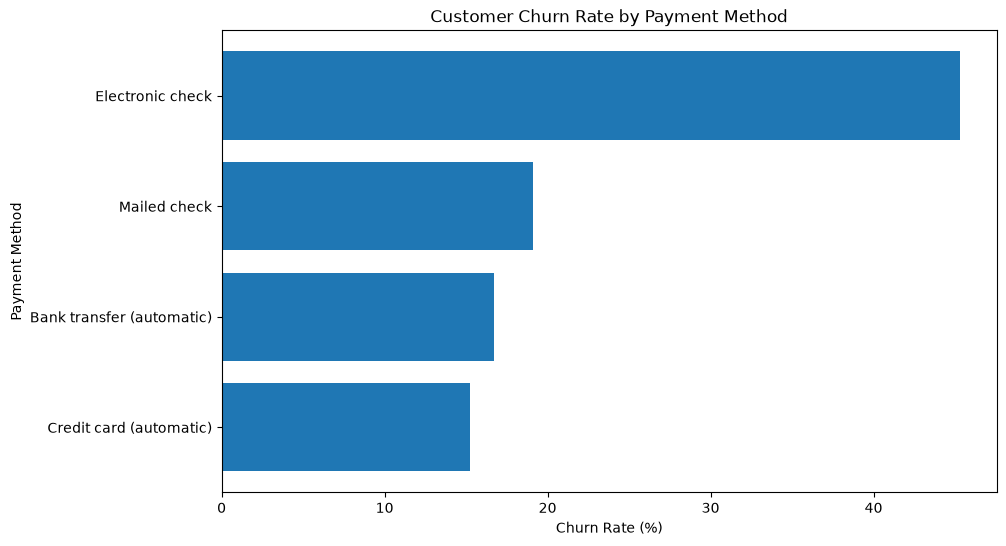

In [17]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=True)
)

payment_churn
plt.figure(figsize=(10,6))

plt.barh(
    payment_churn.index,
    payment_churn.values
)

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Payment Method")

plt.show()

Customer Churn Rate by Payment Method

The analysis reveals a substantial difference in customer churn rates across payment methods. Customers who use **Electronic Check** have the highest churn rate at **45.29%**, meaning that nearly half of the customers in this group have discontinued their services. This is considerably higher than the churn rates observed among customers using **Mailed Check (19.11%)**, **Bank Transfer (Automatic) (16.71%)**, and **Credit Card (Automatic) (15.24%)**.

The results show a clear pattern in which customers using automatic payment methods have substantially lower churn rates than customers using Electronic Check. Customers paying through Credit Card (Automatic) and Bank Transfer (Automatic) have churn rates of **15.24%** and **16.71%**, respectively, compared with **45.29%** among Electronic Check users.

### Business Insight

Payment method appears to be an important factor associated with customer retention. The significantly higher churn rate among Electronic Check users may indicate that these customers have lower payment commitment or may be more likely to reconsider their subscription each billing period. In contrast, automatic payment methods may encourage greater continuity by making payments more convenient and reducing the possibility of missed or delayed payments.

However, the analysis identifies an association rather than proving that the payment method itself causes customer churn. Payment method may also be related to other customer characteristics, such as contract type, tenure, or customer demographics, which could contribute to the observed difference.

### Recommendation

The company should investigate the reasons behind the high churn rate among Electronic Check users and consider encouraging these customers to switch to automatic payment methods. Incentives such as small discounts, promotional offers, or additional service benefits could encourage customers to adopt automatic payment options.

The company should also prioritize Electronic Check customers for proactive retention campaigns, particularly when combined with other high-risk characteristics such as short tenure, month-to-month contracts, or high monthly charges. Encouraging more convenient and consistent payment methods could potentially improve payment continuity and contribute to stronger long-term customer retention.

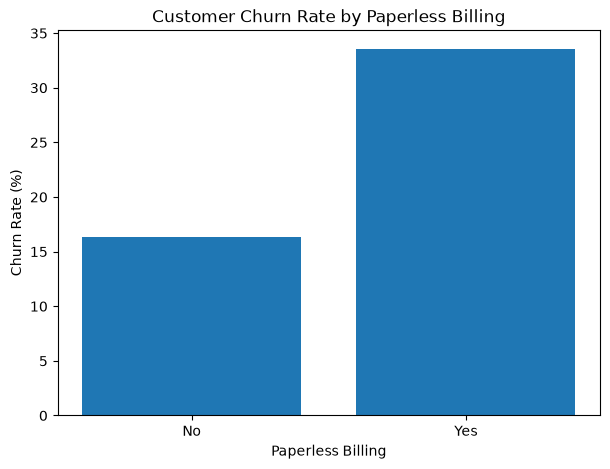

In [19]:
paperless_churn = (
    df.groupby("PaperlessBilling")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

paperless_churn
plt.figure(figsize=(7,5))

plt.bar(
    paperless_churn.index,
    paperless_churn.values
)

plt.title("Customer Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")

plt.show()

Customer Churn Rate by Paperless Billing

The analysis reveals a notable difference in customer churn rates based on Paperless Billing status. Customers who use **Paperless Billing** have a churn rate of **33.57%**, which is substantially higher than the **16.33%** churn rate among customers who do not use Paperless Billing. This indicates that customers enrolled in Paperless Billing are approximately twice as likely to churn as customers who receive traditional billing.

The difference suggests that Paperless Billing is associated with a higher likelihood of customer attrition. However, this finding does not necessarily mean that Paperless Billing directly causes customers to churn. Customers who use Paperless Billing may also have other characteristics, such as shorter contract commitments, higher monthly charges, or different payment methods, that contribute to their higher churn risk.

### Business Insight

Paperless Billing appears to be an important characteristic associated with customer churn. The higher churn rate among Paperless Billing customers may reflect differences in customer behavior or the types of customers who prefer digital billing rather than dissatisfaction with the billing method itself.

This finding should therefore be investigated alongside other customer characteristics. In particular, the company should examine whether Paperless Billing customers are more likely to use **Electronic Check**, have **month-to-month contracts**, or have **shorter customer tenures**, as these factors may help explain the higher churn rate observed in this segment.

### Recommendation

The company should avoid treating Paperless Billing itself as a direct cause of churn. Instead, Paperless Billing customers should be considered a potential high-risk segment for further investigation. The company should analyze their broader customer profiles and identify whether additional factors are driving their higher churn rate.

If the analysis confirms that Paperless Billing customers are more likely to combine with other high-risk characteristics, the company can develop targeted retention campaigns, personalized offers, and proactive customer engagement strategies for this segment. The company should also ensure that digital billing communications are clear, timely, and easy to understand to maintain a positive customer experience.

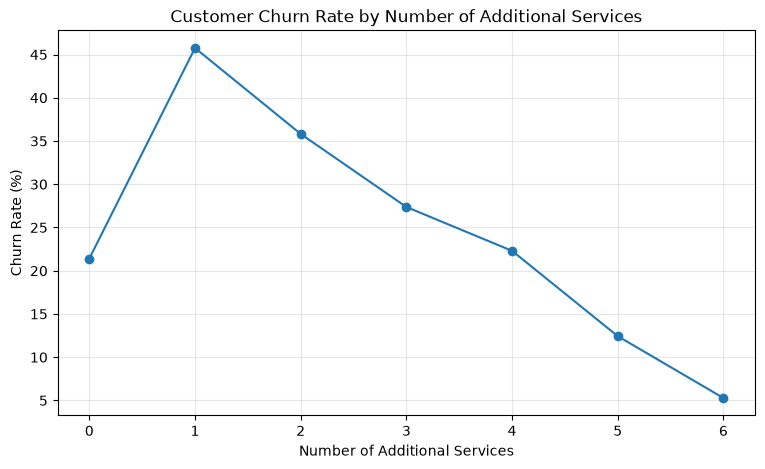

In [21]:
df["AdditionalServices"] = (
    (df["OnlineSecurity"] == "Yes").astype(int)
    + (df["OnlineBackup"] == "Yes").astype(int)
    + (df["DeviceProtection"] == "Yes").astype(int)
    + (df["TechSupport"] == "Yes").astype(int)
    + (df["StreamingTV"] == "Yes").astype(int)
    + (df["StreamingMovies"] == "Yes").astype(int)
)
service_churn = (
    df.groupby("AdditionalServices")["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

service_churn
plt.figure(figsize=(9,5))

plt.plot(
    service_churn.index,
    service_churn.values,
    marker="o"
)

plt.title("Customer Churn Rate by Number of Additional Services")
plt.xlabel("Number of Additional Services")
plt.ylabel("Churn Rate (%)")

plt.grid(alpha=0.3)

plt.show()

Customer Churn Rate by Number of Additional Services

The analysis reveals an interesting relationship between the number of additional services subscribed to by customers and their likelihood of churning. Customers with **1 additional service** have the highest churn rate at **45.76%**, followed by customers with **2 additional services (35.82%)** and **3 additional services (27.37%)**.

As the number of additional services increases beyond three, the churn rate generally declines. Customers with **4 additional services** have a churn rate of **22.30%**, while those with **5 additional services** have a much lower churn rate of **12.43%**. Customers subscribed to all **6 additional services** have the lowest churn rate at only **5.28%**.

Interestingly, customers with **0 additional services** have a churn rate of **21.41%**, which is lower than customers with 1, 2, or 3 additional services. This suggests that the relationship between service adoption and churn is not strictly linear. The particularly high churn rate among customers with only one additional service may indicate that these customers have limited engagement with the company's broader service offerings.

### Business Insight

The findings suggest that customers who adopt a greater number of additional services tend to have significantly lower churn rates. Customers subscribed to all six additional services have a churn rate of only **5.28%**, compared with **45.76%** among customers with just one additional service.

This pattern may indicate that customers who use multiple services are more deeply engaged with the company and may perceive greater overall value from their subscription. Having multiple products and services may also increase customer dependency on the provider and create stronger customer relationships, reducing the likelihood of switching to competitors.

However, the analysis identifies an association rather than proving that subscribing to more services directly prevents churn. Other factors, such as tenure, contract type, internet service, and monthly charges, may also contribute to the observed relationship.

### Recommendation

The company should explore **service bundling and cross-selling strategies** to increase customer engagement and strengthen customer relationships. Customers with limited service adoption, particularly those with only one additional service, could be targeted with personalized recommendations, discounted bundles, or introductory offers for complementary services.

Rather than simply encouraging customers to purchase more services, the company should identify combinations that provide genuine value to each customer segment. Customers who adopt multiple relevant services appear to have substantially lower churn rates, suggesting that increasing meaningful service engagement could be an effective component of the company's broader customer retention strategy.

## Key Insights: Customer Services and Churn Analysis

The analysis of customer service usage and billing characteristics reveals several important patterns associated with customer churn.

1. **Online Security is strongly associated with customer retention.** Customers without Online Security have a churn rate of **41.77%**, compared with only **14.61%** among customers who subscribe to the service. This identifies customers without Online Security as a high-risk segment that may benefit from targeted service bundles and retention offers.

2. **Tech Support shows a similar retention pattern.** Customers without Tech Support have a churn rate of **41.64%**, while customers with Tech Support have a significantly lower churn rate of **15.17%**. This suggests that access to technical assistance may be associated with stronger customer engagement and retention.

3. **Electronic Check users represent a particularly high-risk customer segment.** Customers using Electronic Check have the highest churn rate among all payment methods at **45.29%**, compared with **15.24%** for customers using automatic credit card payments and **16.71%** for automatic bank transfers. The company should investigate the characteristics of Electronic Check users and encourage suitable customers to adopt more convenient automatic payment methods.

4. **Paperless Billing is associated with higher churn.** Customers using Paperless Billing have a churn rate of **33.57%**, more than twice the **16.33%** observed among customers who do not use Paperless Billing. However, this relationship should be investigated alongside other factors such as payment method, contract type, tenure, and monthly charges before concluding that Paperless Billing itself contributes to churn.

5. **Customer engagement through multiple services is associated with lower churn.** Customers with only one additional service have the highest churn rate at **45.76%**, while customers using all six additional services have the lowest churn rate at just **5.28%**. Overall, churn generally declines as customers adopt more additional services, suggesting that deeper engagement with the company's service ecosystem may be associated with stronger customer retention.

### Overall Business Insight

Taken together, the findings suggest that customer engagement and service adoption are important characteristics associated with customer retention. Customers who lack additional services such as Online Security and Tech Support, rely on Electronic Check payments, or have limited engagement with the company's broader service offerings appear to represent higher-risk customer segments.

The results suggest that the company could improve retention by increasing meaningful customer engagement through **personalized service bundles, targeted cross-selling, proactive technical support, and convenient payment options**. However, these findings represent associations rather than evidence of direct causation. Further analysis should examine how these factors interact with other major churn drivers, particularly **tenure, contract type, monthly charges, and internet service**, to identify the customer profiles that are most vulnerable to churn.

### Priority Retention Opportunities

Based on the observed churn rates, the company should prioritize:

- **Electronic Check customers** — 45.29% churn rate.
- **Customers with one additional service** — 45.76% churn rate.
- **Customers without Online Security** — 41.77% churn rate.
- **Customers without Tech Support** — 41.64% churn rate.
- **Paperless Billing customers** — 33.57% churn rate.

These segments should be investigated further to determine whether their elevated churn is driven by specific combinations of customer characteristics. Identifying these overlapping risk factors will allow the company to develop more precise and cost-effective retention strategies.